环境准备

In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("DEBUG")
import pandas as pd
import numpy as np
from cfe.data import FateAnnData
import matplotlib.pyplot as plt
import seaborn as sns
from cfe.metric import calculate_metrics

[2025年10月20日 17时50分19秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据准备和预处理

In [2]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("/home/huang/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad")
fadata = cfe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"
cluster_key = "clusters"

fadata.obs.index = [f"cell_{i:03d}" for i in range(fadata.shape[0])]
fadata

[2025年10月20日 17时50分20秒] DEBUG    Create a FateAnnData object from an existing AnnData object.                


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

简单的预处理流程

In [3]:
sc.pp.normalize_total(fadata)
sc.pp.log1p(fadata)
#筛选2400高可变基因
sc.pp.highly_variable_genes(fadata, n_top_genes=2400)
fadata = fadata[:, fadata.var.highly_variable]
fadata

[2025年10月20日 17时50分21秒] DEBUG    Create a FateAnnData object from an existing AnnData object.                


AnnData object with n_obs × n_vars = 3696 × 2400
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'log1p', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [4]:
# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
    ],
    columns=["from", "to"],
)

fadata.add_trajectory_mannually(milestone_network)

                        DEBUG    FateAnnData add_trajectory                                                        


参考的轨迹结构图绘制

[2025年10月20日 17时50分34秒] DEBUG    plot_trajectory                                                             
[2025年10月20日 17时50分44秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年10月20日 17时50分47秒] DEBUG    add waypoints shape is (212, 3696), finished!                               


<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

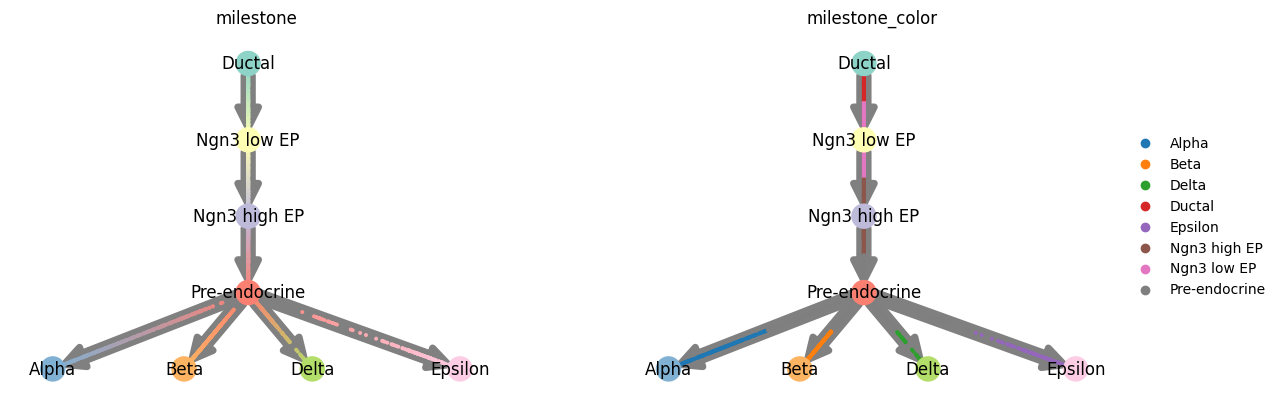

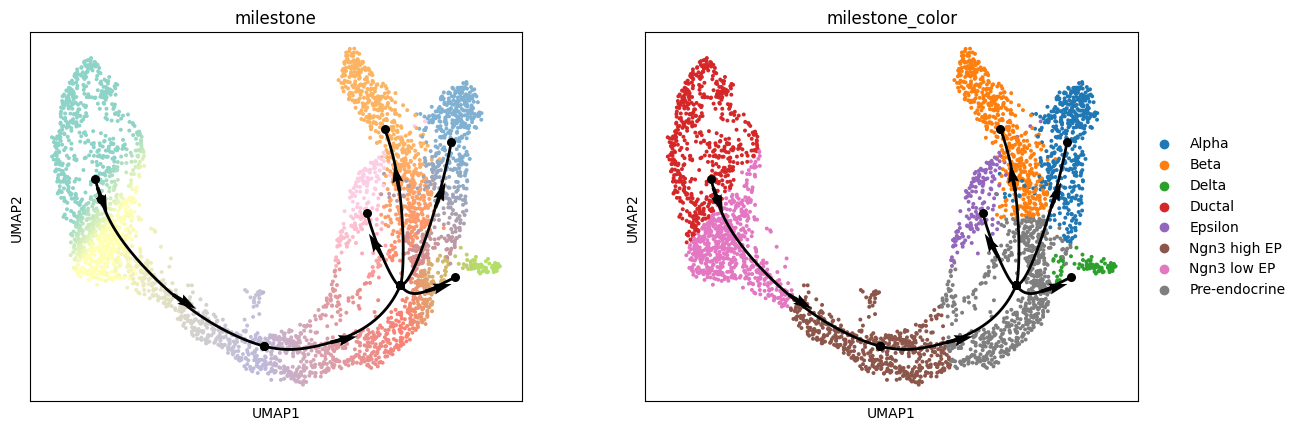

In [5]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key)  # new cluster color

cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

添加先验知识

In [6]:
prior_information = {"start_id": fadata.obs.index[0], "groups_id": fadata.obs[cluster_key].tolist()}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata

绘制模型推断出的轨迹图

[2025年10月20日 17时51分10秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_comp1 at 0x78ad9c215cf0> from                       
                                 /home/mhn/Code/CellFateExplorer/cfe/method/function/cf_comp1.py                   
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x78ad9c0a6ce0>                                                                   
                        DEBUG    Add trajectory by wrapper type: linear                                            
                        DEBUG    Wrapper type: linear                                                              
                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    plot_trajectory                              

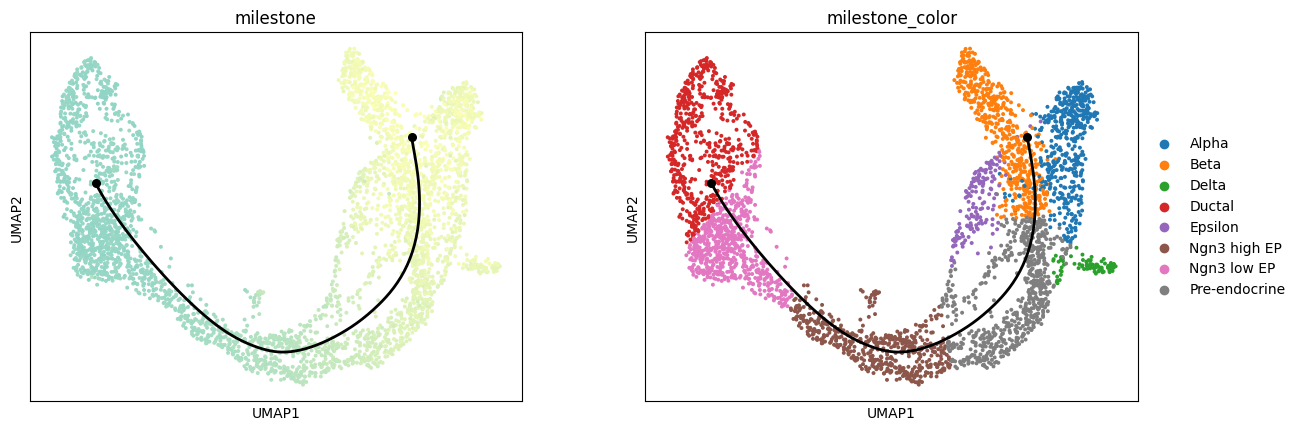

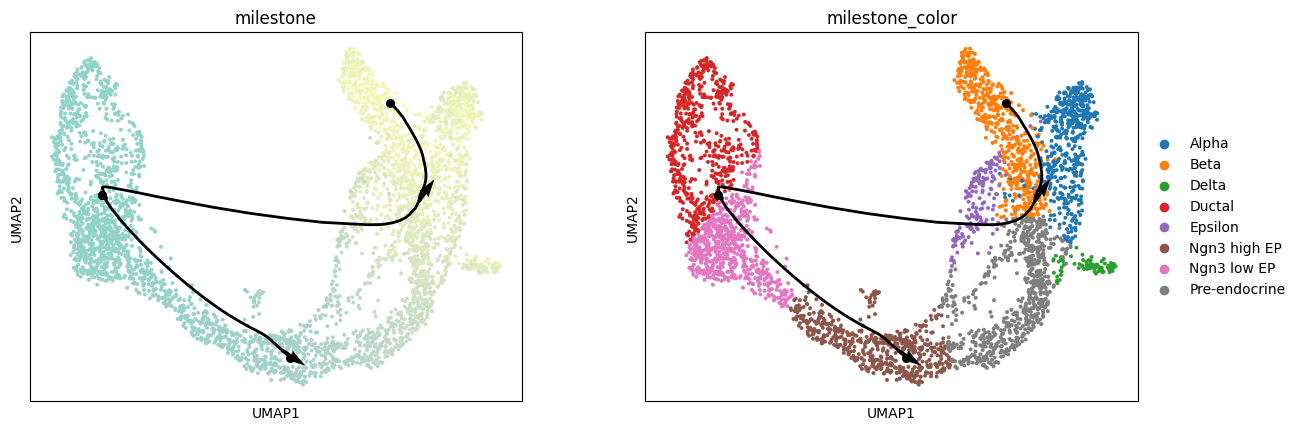

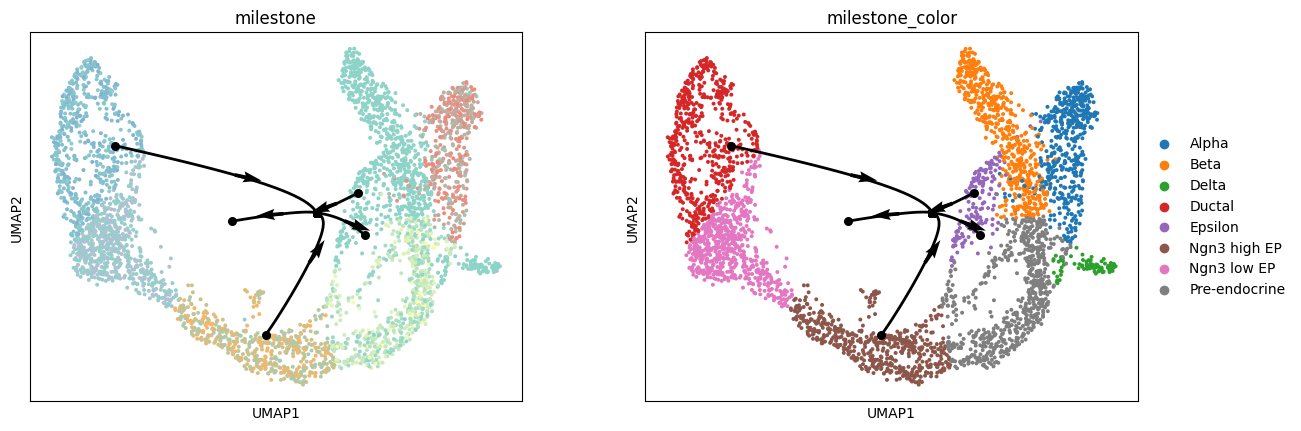

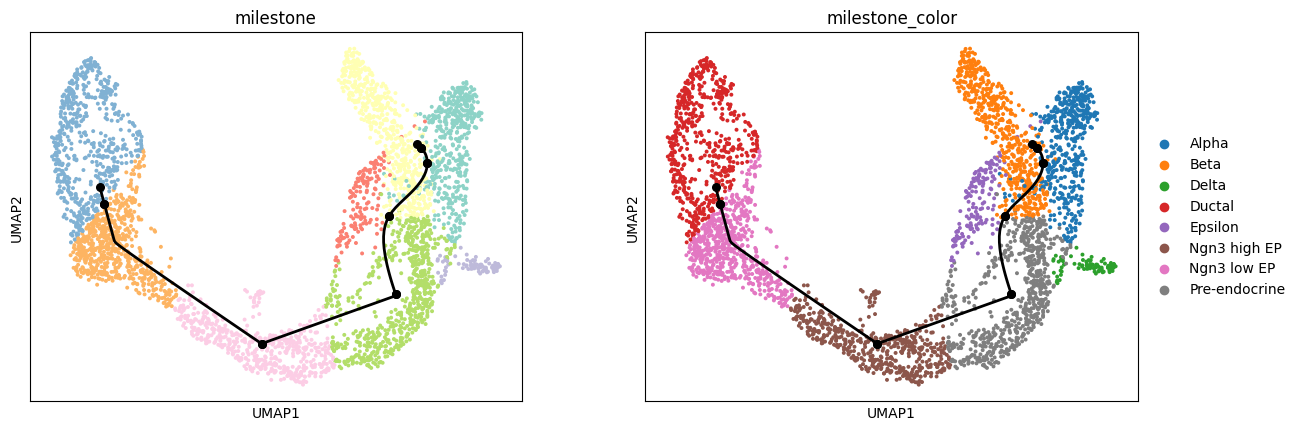

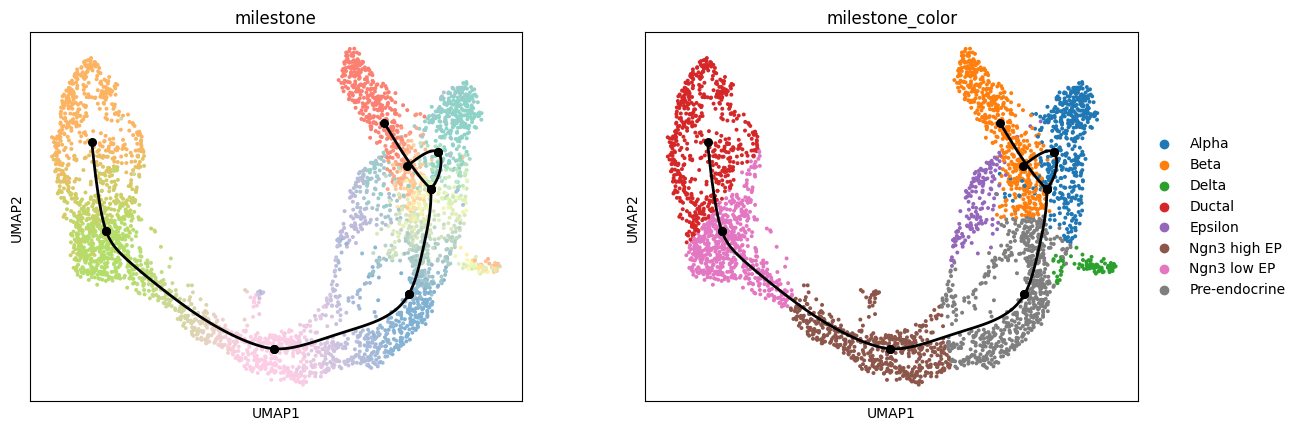

In [7]:
method_name_list = ["comp1", "state_comp", "paga", "cluster_mst", "projection_mst"]
for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata)
    cfe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)

这里需要构造新的fadata与计算接口兼容，原生fadata嵌套结构与接口不兼容

In [8]:

new_fadata=cfe.data.FateAnnData(X=fadata.X, obs=fadata.obs, uns=fadata.uns)
#除此之外还要为新的fadata添加必要的属性，与旧的fadata保持一致
for i in fadata.get_all_model_name(parse=False):
    new_fadata.model_name = i
    new_fadata.milestone_wrapper = fadata.trajectory_history_dict[i]["milestone_wrapper"]
    new_fadata.add_waypoints()

#先验
prior_information = {"start_id": fadata.obs.index[0], "groups_id": fadata.obs[cluster_key].tolist()}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
new_fadata.add_prior_information(**prior_information)  # add prior information to fadata

[2025年10月20日 17时53分33秒] DEBUG    FateAnnData add_waypoints                                                   
[2025年10月20日 17时53分35秒] DEBUG    FateAnnData add_waypoints                                                   
[2025年10月20日 17时53分39秒] DEBUG    FateAnnData add_waypoints                                                   
[2025年10月20日 17时53分44秒] DEBUG    FateAnnData add_waypoints                                                   
[2025年10月20日 17时53分49秒] DEBUG    FateAnnData add_waypoints                                                   
[2025年10月20日 17时53分51秒] DEBUG    FateAnnData add_waypoints                                                   


指标计算

In [9]:
calculate_metrics(new_fadata, now_model=fadata.get_all_model_name(parse=False), ref_model="ref")

,isomorphic,edge_flip,him,correlation,F1_branches,F1_milestones,rf_mse,rf_nmse,rf_rsq,lm_nmse,lm_mse,lm_rsq,featureimp_cor,featureimp_wcor
ref,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,5.590169e-07,0.999993,0.999989,1.000000,0.000000,1.000000,1.000000,1.000000
20251020_175110__comp1-python_function__JANfxrDMFW,0.0,0.000000,0.267002,0.792417,0.189011,0.285510,6.033959e-02,0.242836,0.254755,0.218401,0.062287,0.173732,0.680986,0.689505
20251020_175126__state_comp-python_function__zgCy8SWleR,0.0,0.400000,0.205989,0.000000,0.320251,0.228036,3.974646e-02,0.501246,0.453506,0.379418,0.049455,0.324660,0.766776,0.747905
20251020_175143__paga-python_function__69aJr9u38i,0.0,0.000000,0.588667,0.121872,0.477617,0.417973,2.109768e-02,0.735258,0.614820,0.584680,0.033097,0.494847,0.943682,0.896515
20251020_175202__cluster_mst-python_function__Ilfaxv8Z86,0.0,0.000000,0.267002,0.000000,0.528624,1.000000,7.556056e-03,0.905184,0.896929,0.905195,0.007555,0.896930,0.990539,0.978962
20251020_175217__projection_mst-python_function__itOrBteDxh,0.0,0.666667,0.265559,0.000000,0.593720,0.634783,1.850300e-02,0.767817,0.675360,0.823716,0.014048,0.743615,0.979065,0.962997
